<a href="https://colab.research.google.com/github/splakplutoy/tugas-sisdas-cv/blob/main/tugas_sisdas_cv_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
# Tetap gunakan Keras versi 2 (Legacy) agar Teachable Machine aman
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from google.colab import drive
import kagglehub

# 1. Menyambungkan Google Drive
drive.mount('/content/drive')

path_kustom = '/content/drive/MyDrive/Model Tugas CNN/Model Custom/model_kustom_qc.h5'
path_tm = '/content/drive/MyDrive/Model Tugas CNN/Model Teachable Machine/keras_model.h5'

# 2. Memuat Model Teachable Machine (Keras 2)
print("\nMemuat Model Teachable Machine...")
model_tm = tf.keras.models.load_model(path_tm, compile=False)

# 3. Memuat Model Custom dengan Trik "Load Weights"
print("Memuat Model Custom (Keras)...")
# a. Bangun ulang "rangka" arsitektur yang persis sama dengan Fase 3
model_kustom = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(300, 300, 1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# b. Suntikkan "otaknya" (hanya mengambil nilai weights, mengabaikan versi Keras)
model_kustom.load_weights(path_kustom)
print("✅ Kedua model berhasil masuk ke arena tanpa ribut versi!")

# 4. Menyiapkan Dataset Testing
print("\nMengunduh dataset untuk evaluasi...")
dataset_path = kagglehub.dataset_download("ravirajsinh45/real-life-industrial-dataset-of-casting-product")

base_dir = os.path.join(dataset_path, 'casting_data', 'casting_data')
if not os.path.exists(base_dir):
    base_dir = os.path.join(dataset_path, 'casting_data')

test_dir = os.path.join(base_dir, 'test')
print(f"✅ Folder data testing siap di: {test_dir}")

Mounted at /content/drive

Memuat Model Teachable Machine...
Memuat Model Custom (Keras)...
✅ Kedua model berhasil masuk ke arena tanpa ribut versi!

Mengunduh dataset untuk evaluasi...


100%|██████████| 100M/100M [00:00<00:00, 201MB/s] 

Extracting files...


✅ Folder data testing siap di: /root/.cache/kagglehub/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/versions/2/casting_data/casting_data/test


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# =======================================================
# 1. Pipa Data untuk Model Custom
# =======================================================
test_datagen_kustom = ImageDataGenerator(rescale=1./255)

print("Menyiapkan Data Ujian untuk Model Custom...")
test_generator_kustom = test_datagen_kustom.flow_from_directory(
    test_dir,
    target_size=(300, 300),
    color_mode='grayscale',
    batch_size=32,
    class_mode='binary',
    shuffle=False  # SANGAT PENTING: Jangan diacak agar tebakan AI sejajar dengan kunci jawaban!
)

# =======================================================
# 2. Pipa Data untuk Model Teachable Machine
# =======================================================
# Rumus wajib bawaan Google TM untuk normalisasi piksel (-1 sampai 1)
def tm_preprocessing(img):
    return (img / 127.5) - 1.0

test_datagen_tm = ImageDataGenerator(preprocessing_function=tm_preprocessing)

print("\nMenyiapkan Data Ujian untuk Model Teachable Machine...")
test_generator_tm = test_datagen_tm.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=32,
    class_mode='binary',
    shuffle=False  # SANGAT PENTING: Jangan diacak!
)

# =======================================================
# 3. Cek Sinkronisasi Kunci Jawaban
# =======================================================
print("\nKunci Jawaban Kelas Custom :", test_generator_kustom.class_indices)
print("Kunci Jawaban Kelas TM     :", test_generator_tm.class_indices)

Menyiapkan Data Ujian untuk Model Custom...
Found 715 images belonging to 2 classes.

Menyiapkan Data Ujian untuk Model Teachable Machine...
Found 715 images belonging to 2 classes.

Kunci Jawaban Kelas Custom : {'def_front': 0, 'ok_front': 1}
Kunci Jawaban Kelas TM     : {'def_front': 0, 'ok_front': 1}


Model Custom sedang mengerjakan ujian...
23/23 [==============================] - 57s 2s/step

Model Teachable Machine sedang mengerjakan ujian...
23/23 [==============================] - 11s 476ms/step



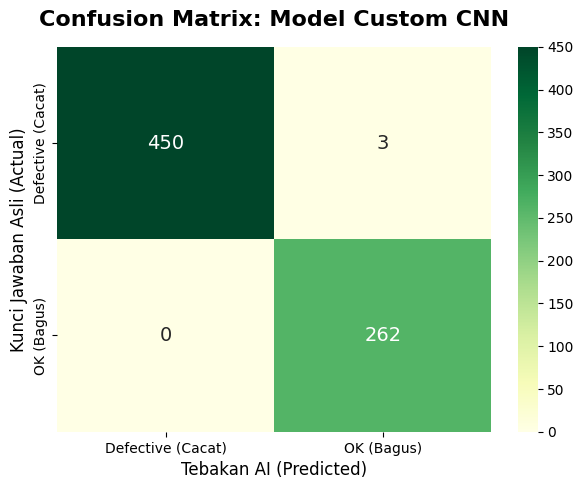


Rapor Detail Confusion Matrix: Model Custom CNN:
                   precision    recall  f1-score   support

Defective (Cacat)       1.00      0.99      1.00       453
       OK (Bagus)       0.99      1.00      0.99       262

         accuracy                           1.00       715
        macro avg       0.99      1.00      1.00       715
     weighted avg       1.00      1.00      1.00       715




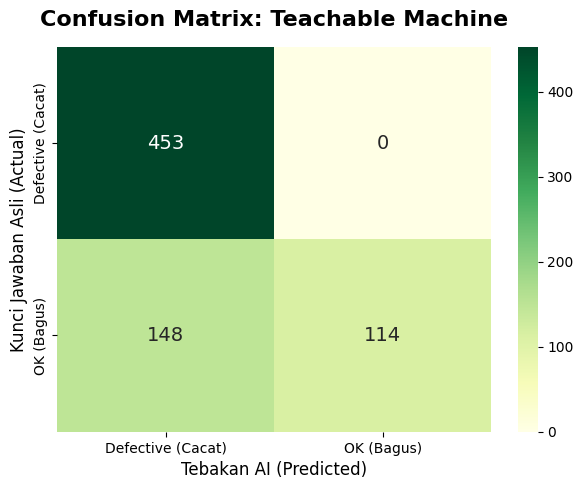


Rapor Detail Confusion Matrix: Teachable Machine:
                   precision    recall  f1-score   support

Defective (Cacat)       0.75      1.00      0.86       453
       OK (Bagus)       1.00      0.44      0.61       262

         accuracy                           0.79       715
        macro avg       0.88      0.72      0.73       715
     weighted avg       0.84      0.79      0.77       715



In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Mengambil Kunci Jawaban Asli dari Generator
y_true = test_generator_kustom.classes
class_names = ['Defective (Cacat)', 'OK (Bagus)']

# 2. Proses Ujian Model Custom
print("Model Custom sedang mengerjakan ujian...")
# Model ini mengeluarkan angka probabilitas tunggal (contoh: 0.8)
pred_prob_kustom = model_kustom.predict(test_generator_kustom)
# Jika tebakan > 0.5, anggap sebagai kelas 1 (OK), sisanya 0 (Defective)
y_pred_kustom = (pred_prob_kustom > 0.5).astype(int).reshape(-1)

# 3. Proses Ujian Model Teachable Machine
print("\nModel Teachable Machine sedang mengerjakan ujian...")
# Model TM mengeluarkan 2 angka probabilitas untuk setiap kelas (contoh: [0.1, 0.9])
pred_prob_tm = model_tm.predict(test_generator_tm)
# Ambil indeks kelas dengan probabilitas tertinggi
y_pred_tm_mentah = np.argmax(pred_prob_tm, axis=1)
y_pred_tm = 1 - y_pred_tm_mentah

# 4. Fungsi untuk Menggambar Confusion Matrix & Rapor
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    # Desain grafik dengan palet warna YlGn (Yellow-Green) dan font sans-serif
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 14})

    plt.title(title, fontname='sans-serif', fontsize=16, pad=15, fontweight='bold')
    plt.ylabel('Kunci Jawaban Asli (Actual)', fontname='sans-serif', fontsize=12)
    plt.xlabel('Tebakan AI (Predicted)', fontname='sans-serif', fontsize=12)
    plt.xticks(fontname='sans-serif')
    plt.yticks(fontname='sans-serif')
    plt.show()

    print(f"\nRapor Detail {title}:")
    print(classification_report(y_true, y_pred, target_names=class_names))

# 5. Menampilkan Hasil Komparasi
print("\n" + "="*60)
plot_cm(y_true, y_pred_kustom, "Confusion Matrix: Model Custom CNN")

print("\n" + "="*60)
plot_cm(y_true, y_pred_tm, "Confusion Matrix: Teachable Machine")

Menampilkan 3 gambar yang salah ditebak oleh Model Custom:


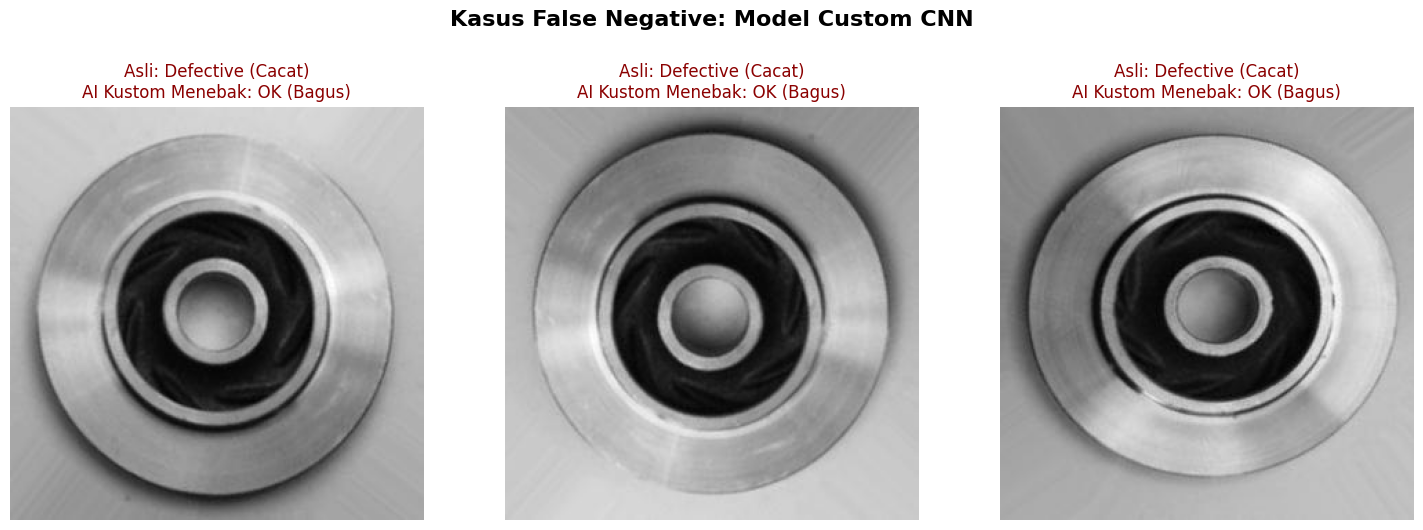


Menampilkan 3 sampel (dari total 148) gambar bagus yang dituduh cacat oleh TM:


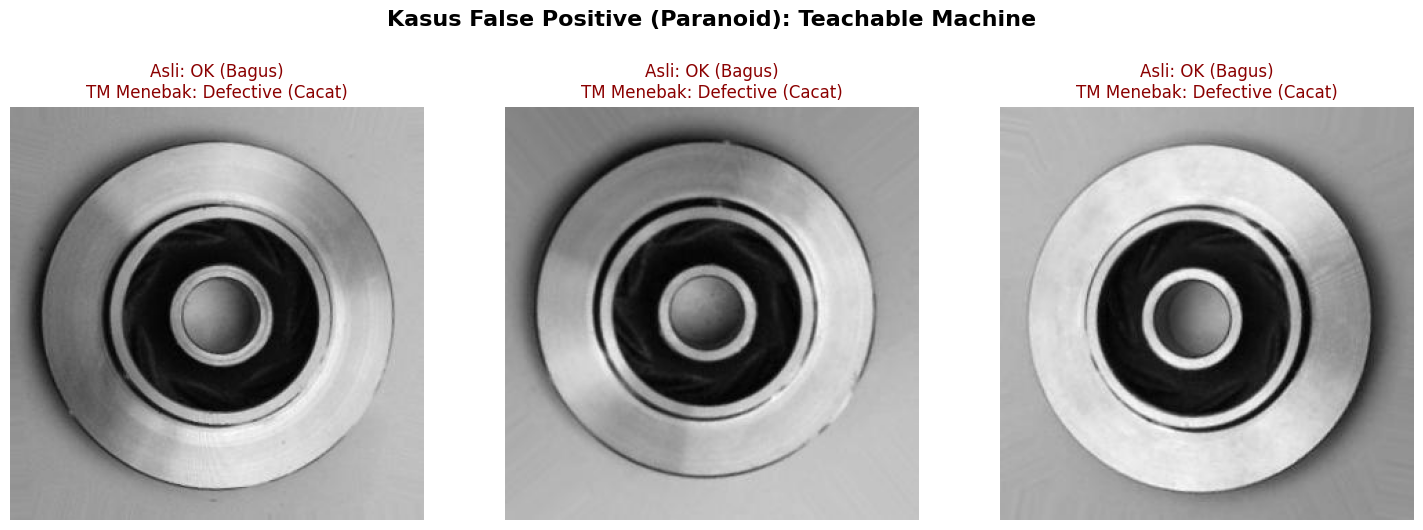

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# =======================================================
# 1. Investigasi Error Model Custom CNN (Cuma 3 Gambar!)
# =======================================================
# Mencari index/posisi gambar di mana Asli tidak sama dengan Tebakan
salah_kustom_idx = np.where(y_true != y_pred_kustom)[0]

print(f"Menampilkan {len(salah_kustom_idx)} gambar yang salah ditebak oleh Model Custom:")

plt.figure(figsize=(15, 5))
for i, idx in enumerate(salah_kustom_idx):
    plt.subplot(1, 3, i+1)

    # Ambil alamat file gambar asli dari generator
    img_path = test_generator_kustom.filepaths[idx]
    img = mpimg.imread(img_path)

    # Tampilkan gambar dalam mode abu-abu
    plt.imshow(img, cmap='gray')

    label_asli = "OK (Bagus)" if y_true[idx] == 1 else "Defective (Cacat)"
    label_tebak = "OK (Bagus)" if y_pred_kustom[idx] == 1 else "Defective (Cacat)"

    plt.title(f"Asli: {label_asli}\nAI Kustom Menebak: {label_tebak}", color='darkred', fontsize=12)
    plt.axis('off')

plt.suptitle("Kasus False Negative: Model Custom CNN", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# =======================================================
# 2. Investigasi Error Teachable Machine (Ambil 3 Sample)
# =======================================================
# Mencari kasus False Positive: Aslinya OK(1), tapi ditebak Cacat(0)
fp_tm_idx = np.where((y_true == 1) & (y_pred_tm == 0))[0]

print(f"\nMenampilkan 3 sampel (dari total {len(fp_tm_idx)}) gambar bagus yang dituduh cacat oleh TM:")

plt.figure(figsize=(15, 5))
for i, idx in enumerate(fp_tm_idx[:3]): # Cukup ambil 3 gambar pertama
    plt.subplot(1, 3, i+1)

    img_path = test_generator_tm.filepaths[idx]
    img = mpimg.imread(img_path)

    plt.imshow(img)

    plt.title(f"Asli: OK (Bagus)\nTM Menebak: Defective (Cacat)", color='darkred', fontsize=12)
    plt.axis('off')

plt.suptitle("Kasus False Positive (Paranoid): Teachable Machine", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()